In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn

In [6]:
print(tf.__version__)
print(pd.__version__)
print(np.__version__)

2.20.0
2.3.3
2.0.2


In [12]:
df_train = pd.read_csv("data/fraudTrain.csv", sep=",",index_col="trans_date_trans_time")
df_test = pd.read_csv("data/fraudTest.csv", sep=",",index_col="trans_date_trans_time")

In [13]:
import os
print(os.getcwd())

D:\Etude\Master cours\Data science\data-sc-env\projet-detection-fraude


In [21]:
df_train.sample(5)

,Unnamed: 0,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
trans_date_trans_time,,,,,,,,,,,,,,,,,,,,,
2019-07-12 22:29:05,432052,4247921790666,"fraud_Moore, Williamson and Emmerich",home,23.72,Judith,Moss,F,46297 Benjamin Plains Suite 703,Washington Court House,...,39.5370,-83.4550,22305,Television floor manager,1939-03-09,a07ed540e7592e3b8c50a5f6dc7cc956,1342132145,40.282412,-83.957834,0
2019-04-18 17:48:11,212438,4198470814557,"fraud_Armstrong, Walter and Gottlieb",food_dining,5.71,Christie,Williamson,F,519 Jerry Views,Avoca,...,41.4768,-95.3509,2036,Engineering geologist,1971-08-20,c3b90ab2b217a960bacf25530dd2c904,1334771291,41.946060,-96.140700,0
2020-04-27 07:14:25,1155786,3562679455732797,fraud_Kuhic LLC,shopping_net,173.60,Amanda,Jones,F,7320 Jennifer Forges,Queenstown,...,39.0026,-76.1424,3862,Maintenance engineer,1962-12-06,22741a835edbc322efaa54277c1e5c6a,1367046865,38.948024,-76.881610,0
2019-12-16 07:22:19,854826,36581538659449,fraud_Miller-Hauck,grocery_pos,76.93,Brandon,Bridges,M,957 Miller Falls,Apison,...,35.0149,-85.0164,3730,Occupational therapist,1991-01-28,a52ecff870ccdeea786d68ffa6800ba2,1355642539,34.363573,-84.814100,0
2019-03-24 01:32:47,154525,6573561108825071,"fraud_Boehm, Block and Jakubowski",misc_pos,3.53,Kristina,Lewis,F,5449 Brandi Heights Apt. 111,Tulsa,...,36.2395,-95.9596,413574,Bookseller,1968-06-18,05689677726b67d7009631d313798a05,1332552767,35.652207,-96.168034,0


In [41]:
df_train.dtypes.value_counts()

object     11
int64       6
float64     5
Name: count, dtype: int64

In [48]:
df_train.duplicated().value_counts()

False    1296675
Name: count, dtype: int64

<Axes: xlabel='gender'>

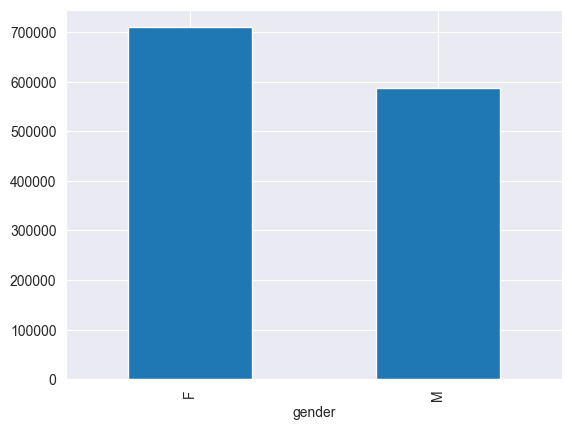

In [34]:
df_train['gender'].value_counts().plot(kind='bar')

In [49]:
df_train.describe(include="all")

,Unnamed: 0,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1296675,1296675,1.296675e+06,1296675,1296675,1296675,1296675,1296675,...,1.296675e+06,1.296675e+06,1.296675e+06,1296675,1296675,1296675,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
unique,NaN,NaN,693,14,NaN,352,481,2,983,894,...,NaN,NaN,NaN,494,968,1296675,NaN,NaN,NaN,NaN
top,NaN,NaN,fraud_Kilback LLC,gas_transport,NaN,Christopher,Smith,F,864 Reynolds Plains,Birmingham,...,NaN,NaN,NaN,Film/video editor,1977-03-23,8f7c8e4ab7f25875d753b422917c98c9,NaN,NaN,NaN,NaN
freq,NaN,NaN,4403,131659,NaN,26669,28794,709863,3123,5617,...,NaN,NaN,NaN,9779,5636,1,NaN,NaN,NaN,NaN
mean,6.483370e+05,4.171920e+17,NaN,NaN,7.035104e+01,NaN,NaN,NaN,NaN,NaN,...,3.853762e+01,-9.022634e+01,8.882444e+04,NaN,NaN,NaN,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,NaN,NaN,1.603160e+02,NaN,NaN,NaN,NaN,NaN,...,5.075808e+00,1.375908e+01,3.019564e+05,NaN,NaN,NaN,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,NaN,...,2.002710e+01,-1.656723e+02,2.300000e+01,NaN,NaN,NaN,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,NaN,NaN,9.650000e+00,NaN,NaN,NaN,NaN,NaN,...,3.462050e+01,-9.679800e+01,7.430000e+02,NaN,NaN,NaN,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,NaN,NaN,4.752000e+01,NaN,NaN,NaN,NaN,NaN,...,3.935430e+01,-8.747690e+01,2.456000e+03,NaN,NaN,NaN,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,NaN,NaN,8.314000e+01,NaN,NaN,NaN,NaN,NaN,...,4.194040e+01,-8.015800e+01,2.032800e+04,NaN,NaN,NaN,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
